# 8.4 因子グラフと厳密推論 (Factor Graphs & Exact Inference)

本ノートブックでは、確率分布の因子分解構造を最も自然かつ精密に表現する**因子グラフ (Factor Graphs)** と、木構造グラフ上で効率的かつ厳密に周辺確率・最尤系列を計算する**Sum-Product アルゴリズム（確率伝播法: Belief Propagation）** および **Max-Sum アルゴリズム（ビタビアルゴリズム）** を学びます。
変数ノードと因子ノードの間で送受信されるメッセージパッシングの数理（**PRML Figure 8.46-8.52**）、マルコフ連鎖におけるフォワード・バックワード伝播の完全実装、およびトレリス線図（格子図、**PRML Figure 8.53**）を用いた最尤パスのバックトラッキング探索を完全実装します。

## 8.4.4 Sum-Product アルゴリズムのメッセージパッシング (PRML Figure 8.46 - 8.52)

因子グラフにおいて、全体の結合分布は局所因子の積として表現されます：
$$ p(\mathbf{x}) = \prod_s f_s(\mathbf{x}_s) $$
木構造グラフ上の任意のノード $x$ の周辺分布 $p(x) = \sum_{\mathbf{x} \setminus \{x\}} p(\mathbf{x})$ は、局所的なメッセージ交換によって計算できます：

### 1. 変数ノード $x$ から因子ノード $f$ へのメッセージ
変数ノード $x$ は、受信先 $f$ 以外のすべての隣接因子から届いたメッセージの積を送信します：
$$ \mu_{x \to f}(x) = \prod_{f' \in \mathrm{ne}(x) \setminus \{f\}} \mu_{f' \to x}(x) $$

### 2. 因子ノード $f$ から変数ノード $x$ へのメッセージ
因子ノード $f$ は、局所ポテンシャル $f(\mathbf{x}_s)$ に受信メッセージを掛け合わせ、$x$ 以外のすべての変数を周辺化（和）して送信します：
$$ \mu_{f \to x}(x) = \sum_{\mathbf{x}_s \setminus \{x\}} f(\mathbf{x}_s) \prod_{y \in \mathrm{ne}(f) \setminus \{x\}} \mu_{y \to f}(y) $$

### 3. 周辺確率の計算
すべてのメッセージが伝播した後、ノード $x$ の周辺確率は隣接するすべての因子からの受信メッセージの積となります：
$$ p(x) \propto \prod_{f \in \mathrm{ne}(x)} \mu_{f \to x}(x) $$

Exact Marginal Probabilities p(x_n) along the Chain:
Node x_0: p(k=0)=0.884, p(k=1)=0.088, p(k=2)=0.028
Node x_1: p(k=0)=0.566, p(k=1)=0.249, p(k=2)=0.186
Node x_2: p(k=0)=0.362, p(k=1)=0.298, p(k=2)=0.340
Node x_3: p(k=0)=0.208, p(k=1)=0.265, p(k=2)=0.527
Node x_4: p(k=0)=0.066, p(k=1)=0.137, p(k=2)=0.797

Most Probable Global Configuration x* (Max-Sum): [0, 2, 2, 2, 2]
Plot saved to: result/fig8_53_trellis_max_sum.png


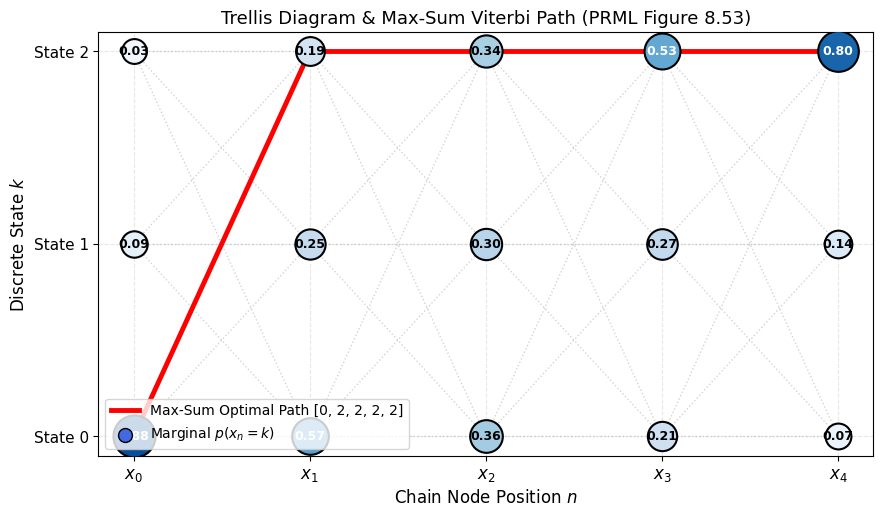

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
from common.graphical_models_utils import SimpleFactorGraphChain
setup_style()

# 5ノードの連鎖グラフ (Hidden Markov Chain / Linear Chain Factor Graph)
# 各ノードは 3 状態 (K=3)
np.random.seed(42)
N_nodes = 5
K_states = 3

# 遷移確率行列 trans[n] (K, K)
trans_matrices = []
for _ in range(N_nodes - 1):
    T = np.array([
        [0.7, 0.2, 0.1],
        [0.15, 0.7, 0.15],
        [0.1, 0.2, 0.7]
    ])
    trans_matrices.append(T)

# 観測ポテンシャル emiss[n] (K,)
# 末端ノード 0 と 4 に強い証拠 (Evidence) があるとする
emiss_potentials = [
    np.array([0.9, 0.08, 0.02]), # x0 は状態 0 が濃厚
    np.array([0.33, 0.33, 0.34]),
    np.array([0.33, 0.33, 0.34]),
    np.array([0.33, 0.33, 0.34]),
    np.array([0.05, 0.1, 0.85]), # x4 は状態 2 が濃厚
]

# Sum-Product (Forward-Backward) による厳密な周辺確率の計算
chain_fg = SimpleFactorGraphChain(K_states, trans_matrices, emiss_potentials)
marginals = chain_fg.forward_backward_marginals()

print("Exact Marginal Probabilities p(x_n) along the Chain:")
for n in range(N_nodes):
    print(f"Node x_{n}: p(k=0)={marginals[n, 0]:.3f}, p(k=1)={marginals[n, 1]:.3f}, p(k=2)={marginals[n, 2]:.3f}")

# 8.4.5 Max-Sum (Viterbi) による最尤パスの探索
log_trans = [np.log(T + 1e-12) for T in trans_matrices]
log_emiss = [np.log(e + 1e-12) for e in emiss_potentials]

# Viterbi 前進ステップ
omega = np.zeros((N_nodes, K_states))
backpointers = np.zeros((N_nodes, K_states), dtype=int)
omega[0] = log_emiss[0]

for n in range(1, N_nodes):
    for k in range(K_states):
        # omega[n, k] = log_emiss[n][k] + max_j (omega[n-1, j] + log_trans[n-1][j, k])
        scores = omega[n-1] + log_trans[n-1][:, k]
        best_prev = np.argmax(scores)
        backpointers[n, k] = best_prev
        omega[n, k] = log_emiss[n][k] + scores[best_prev]

# バックトラッキング
best_path = np.zeros(N_nodes, dtype=int)
best_path[-1] = np.argmax(omega[-1])
for n in range(N_nodes - 2, -1, -1):
    best_path[n] = backpointers[n+1, best_path[n+1]]

print(f"\nMost Probable Global Configuration x* (Max-Sum): {best_path.tolist()}")

# PRML Figure 8.53: トレリス線図 (Trellis Diagram) の描画
fig, ax = plt.subplots(figsize=(10, 5.5))

for n in range(N_nodes):
    for k in range(K_states):
        # 周辺確率に応じた円の大きさと色
        prob = marginals[n, k]
        ax.scatter(n, k, s=300 + 700 * prob, c=[plt.cm.Blues(prob)], edgecolors='k', lw=1.5, zorder=4)
        ax.text(n, k, f"{prob:.2f}", ha='center', va='center', fontsize=9, fontweight='bold',
                color='white' if prob > 0.5 else 'black', zorder=5)

# 遷移エッジの描画
for n in range(N_nodes - 1):
    for k1 in range(K_states):
        for k2 in range(K_states):
            is_optimal = (best_path[n] == k1) and (best_path[n+1] == k2)
            if is_optimal:
                ax.plot([n, n+1], [k1, k2], 'r-', lw=3.5, zorder=3)
            else:
                ax.plot([n, n+1], [k1, k2], color='gray', linestyle=':', alpha=0.35, lw=1.0, zorder=2)

# ダミープロットで凡例
ax.plot([], [], 'r-', lw=3.5, label=f'Max-Sum Optimal Path {best_path.tolist()}')
ax.scatter([], [], s=100, c='royalblue', edgecolors='k', label='Marginal $p(x_n=k)$')

ax.set_xticks(range(N_nodes))
ax.set_xticklabels([f'$x_{n}$' for n in range(N_nodes)], fontsize=12)
ax.set_yticks(range(K_states))
ax.set_yticklabels([f'State {k}' for k in range(K_states)], fontsize=11)
ax.set_title('Trellis Diagram & Max-Sum Viterbi Path (PRML Figure 8.53)', fontsize=13)
ax.set_xlabel('Chain Node Position $n$', fontsize=12)
ax.set_ylabel('Discrete State $k$', fontsize=12)
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

save_plot(fig, 'result', 'fig8_53_trellis_max_sum.png')
plt.show()